In [1]:
from jgw import jgw_solver, jgw_wrapper, generate_d

import math
import matplotlib.pyplot as plt
import numpy as np

from unbalancedgw.vanilla_ugw_solver import exp_ugw_sinkhorn
from unbalancedgw.vanilla_ugw_solver import log_ugw_sinkhorn
from unbalancedgw._vanilla_utils import ugw_cost
from unbalancedgw.utils import generate_measure
from unbalancedgw._vanilla_utils import l2_distortion

import torch

import ot

import time

plt.rcParams["figure.figsize"] = (10,10)

In [2]:
np.random.seed(1)

# Data Generation

In [3]:
b = 1
var = 0.1
arc_size = 200
sq_size = 100


theta = np.random.uniform(0, math.pi, arc_size)
r = b*theta + np.random.normal(0, var, arc_size)
x = np.cos(theta)*r
y = np.sin(theta)*r

mu_y = []
points_y = []
labels = []
for i in range(arc_size):
    mu_y.append(1/(arc_size + sq_size))
    points_y.append([x[i], y[i]])
    labels.append(1)
    
x = np.random.normal(0, 0.1, sq_size)
y = np.random.normal(0, 0.1, sq_size)
for i in range(sq_size):
    mu_y.append(1/(arc_size + sq_size))
    points_y.append([1.5+x[i], 0.5+y[i]])
    labels.append(2)
points_y = np.array(points_y)

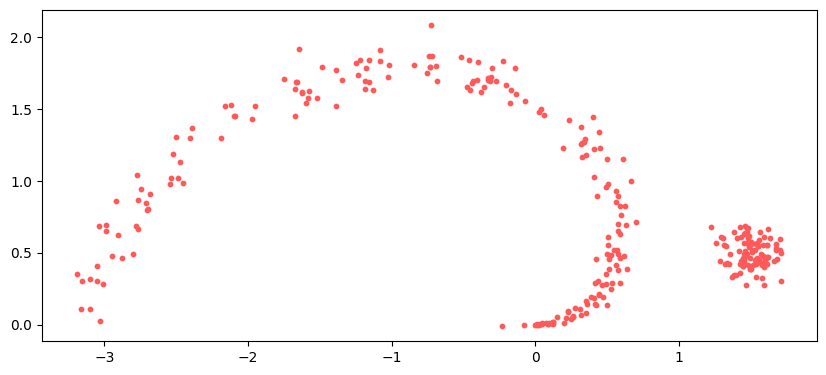

In [4]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_y[0:200,0], points_y[0:200,1], c='#ff5a5a', s=10)
ax.scatter(points_y[200:300,0], points_y[200:300,1], c='#ff5a5a', s=10)
ax.set_aspect('equal', 'box')
plt.savefig('fig/point-target.svg')
plt.show()

In [5]:
theta = np.random.uniform(0, math.pi, arc_size)
r = b*theta + np.random.normal(0, var, arc_size)
x = np.cos(theta)*r
y = np.sin(theta)*r

points_x = [[], []]
mu_x=[]
for i in range(arc_size):
    mu_x.append(1/(arc_size + sq_size))
    points_x[0].append([x[i], y[i]])
points_x[1].append([0,0])
mu_x.append(sq_size/(arc_size+sq_size))
points_x[0] = np.array(points_x[0])
points_x[1] = np.array(points_x[1])

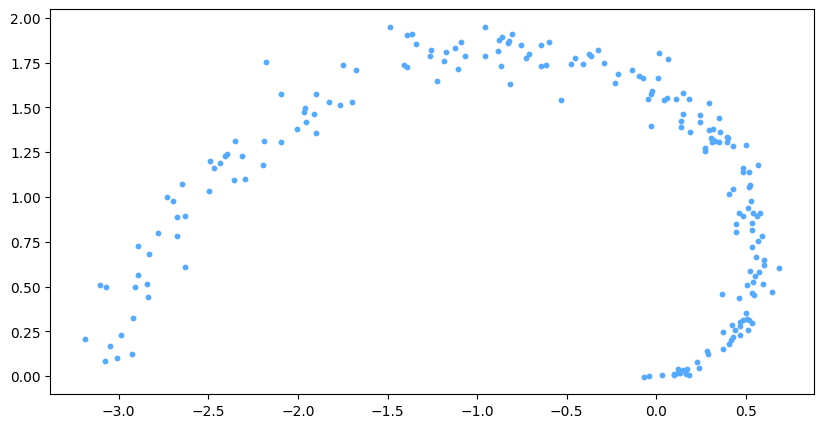

In [6]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_x[0][:,0], points_x[0][:,1], c='#55aaff', s=10)
ax.set_aspect('equal', 'box')
plt.savefig('fig/point-source.svg')
plt.show()

In [7]:
leftmost_ind = 0
mini = 100
for i in range(points_x[0].shape[0]):
    if points_x[0][i][0] < mini:
        mini = points_x[0][i][0]
        leftmost_ind = i
print(leftmost_ind)

188


We also need some utility functions.

In [8]:
def compute_var(row):
    pr = row/row.sum()
    mean_point = np.zeros((2,))
    for i in range(pr.shape[0]):
        mean_point += points_y[i]*pr[i]
    var = 0
    for i in range(pr.shape[0]):
        residue = mean_point - points_y[i]
        var += pr[i]*(residue[0]**2 + residue[1]**2)
    return var

In [9]:
def create_random_perm_mat(shape):
    perm = np.random.permutation(shape[1])
    t_perm = np.zeros(shape)
    for i in range(shape[1]):
        if perm[i] < shape[0]:
            t_perm[perm[i], i] = 1
    res = t_perm/t_perm.sum()
    noise = np.random.rand(shape[0], shape[1])
    res += noise /noise.sum()
    res /= res.sum()
    return res

# JGW

In [10]:
d_y, i_y = generate_d([points_y])
mu_y = np.array(mu_y)

In [11]:
d_x, i_x = generate_d(points_x)
mu_x = np.array(mu_x)

In [12]:
t = time.time()
jgw_mu, difs, costs = jgw_solver(mu_x, mu_y, d_x, d_y, i_x, epsilon=1e-1)
print("Time spent: ", time.time() - t)

c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\ot\bregman\_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\ot\bregman\_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 227
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\ot\bregman\_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Time spent:  2.661776542663574


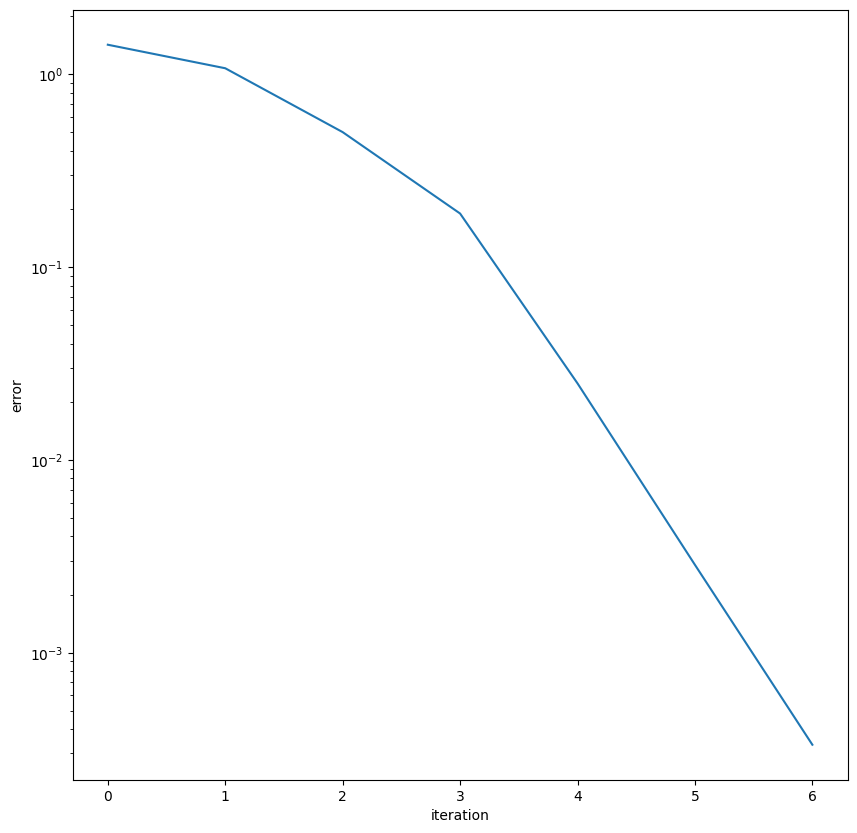

In [13]:
plt.plot(difs)
plt.yscale('log')
plt.ylabel('error')
plt.xlabel('iteration')
plt.show()

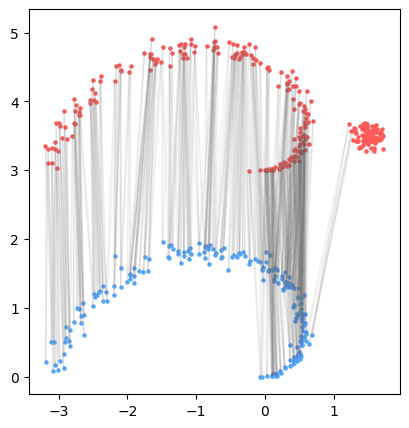

In [14]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_y[:,0], points_y[:,1] + 3, c='#ff5a5a', s=5)
ax.scatter(points_x[0][:,0], points_x[0][:,1], c='#55aaff', s=5)
ax.set_aspect('equal', 'box')

thresh = 1/10000
for i in range(jgw_mu.shape[0] - 1):
    for j in range(jgw_mu.shape[1]):
        if jgw_mu[i,j] > thresh:
            ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'gray', 
                    alpha=100*jgw_mu[i][j], lw=1)
plt.savefig('fig/JGW-coupling.svg')
plt.show()

In [15]:
print("JGW error: %.2f%% "%(100*jgw_mu[0:200, 200:300].sum() / jgw_mu[0:200, :].sum(),))

JGW error: 1.43% 


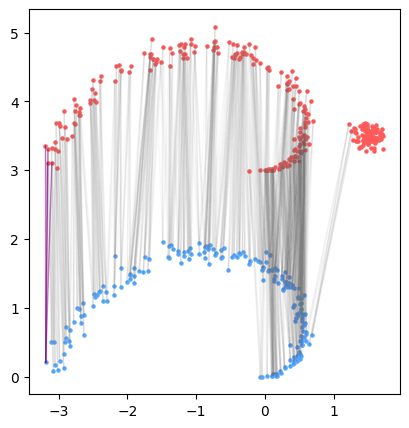

In [16]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_y[:,0], points_y[:,1] + 3, c='#ff5a5a', s=5)
ax.scatter(points_x[0][:,0], points_x[0][:,1], c='#55aaff', s=5)
ax.set_aspect('equal', 'box')

thresh = 1/10000
for i in range(jgw_mu.shape[0] - 1):
    for j in range(jgw_mu.shape[1]):
        if jgw_mu[i,j] > thresh:
            if i!= leftmost_ind:
                ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'gray', 
                        alpha=100*jgw_mu[i][j], lw=1)
            else:
                ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'purple', 
                        alpha=0.5, lw=1)
plt.savefig('fig/JGW-coupling-v1.svg')
plt.show()

In [17]:
jgw_vars = []
for i in range(points_x[0].shape[0]):
    jgw_vars.append(compute_var(jgw_mu[i]))
print("Average variance for JGW: ", np.mean(jgw_vars))

Average variance for JGW:  0.03672172564176741


# UGW

In [18]:
a = [1/points_x[0].shape[0]] * points_x[0].shape[0]
b = [1/points_y.shape[0]] * points_y.shape[0]
n = points_x[0].shape[0]
dx = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dx[i][j] = np.linalg.norm(points_x[0][i] - points_x[0][j])

n = points_y.shape[0]
dy = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dy[i][j] = np.linalg.norm(points_y[i] - points_y[j])

a = torch.from_numpy(np.array(a))
b = torch.from_numpy(np.array(b))
dx = torch.from_numpy(np.array(dx))
dy = torch.from_numpy(np.array(dy))

In [19]:
t0 = time.time()
ugw_mu, gamma = log_ugw_sinkhorn(a, dx, b, dy, eps=1e-2, two_outputs=True)
print("Time spent: ", time.time() - t)

Time spent:  42.91293692588806


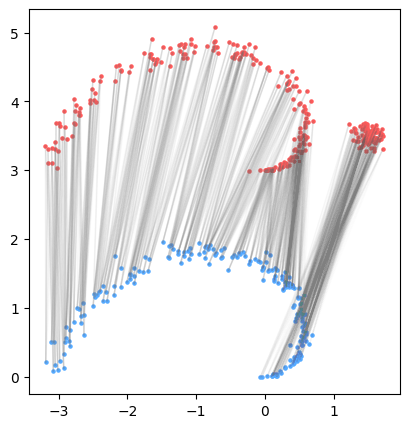

In [20]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_y[:,0], points_y[:,1] + 3, c='#ff5a5a', s=5)
ax.scatter(points_x[0][:,0], points_x[0][:,1], c='#55aaff', s=5)
ax.set_aspect('equal', 'box')

thresh = 1/10000
for i in range(ugw_mu.shape[0] - 1):
    for j in range(ugw_mu.shape[1]):
        if ugw_mu[i,j] > thresh:
            ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'gray', 
                    alpha=100*float(ugw_mu[i][j]), lw=1)
plt.savefig('fig/UGW-coupling.svg')
plt.show()

In [21]:
print("UGW error: %.2f%%"%(100*np.array(ugw_mu)[:,200:300].sum() / np.array(ugw_mu)[:,:].sum(),))

UGW error: 33.33%


C:\Users\artaj\AppData\Local\Temp\ipykernel_27012\1998186287.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print("UGW error: %.2f%%"%(100*np.array(ugw_mu)[:,200:300].sum() / np.array(ugw_mu)[:,:].sum(),))


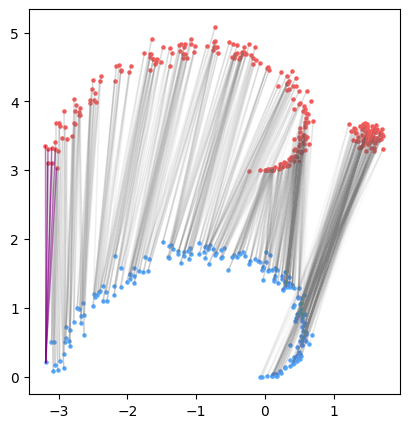

In [22]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_y[:,0], points_y[:,1] + 3, c='#ff5a5a', s=5)
ax.scatter(points_x[0][:,0], points_x[0][:,1], c='#55aaff', s=5)
ax.set_aspect('equal', 'box')

thresh = 1/10000
for i in range(ugw_mu.shape[0] - 1):
    for j in range(ugw_mu.shape[1]):
        if ugw_mu[i,j] > thresh:
            if i!= leftmost_ind:
                ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'gray', 
                        alpha=100*float(ugw_mu[i][j]), lw=1)
            else:
                ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'purple', 
                        alpha=0.5, lw=1)
plt.savefig('fig/UGW-coupling-v1.svg')
plt.show()

In [23]:
ugw_vars = []
for i in range(points_x[0].shape[0]):
    ugw_vars.append(compute_var(np.array(ugw_mu[i])))
print("Average variance for JGW: ", np.mean(ugw_vars))

Average variance for JGW:  0.04354654455423772


C:\Users\artaj\AppData\Local\Temp\ipykernel_27012\2242593149.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ugw_vars.append(compute_var(np.array(ugw_mu[i])))


# PGW

**Note:** For this part you need to clone [PGW github](https://github.com/mint-vu/PGW_Metric) in order to run the _Partial Gromov Wasserstein_ distance.

In [24]:
from pgwlib.unbalanced_gromov_wasserstein.unbalancedgw.vanilla_ugw_solver import exp_ugw_sinkhorn,log_ugw_sinkhorn
from pgwlib.unbalanced_gromov_wasserstein.unbalancedgw._vanilla_utils import ugw_cost
from pgwlib.unbalanced_gromov_wasserstein.unbalancedgw.utils import generate_measure
from pgwlib.unbalanced_gromov_wasserstein.unbalancedgw.batch_stable_ugw_solver import log_batch_ugw_sinkhorn
from pgwlib.gromov import gromov_wasserstein, cost_matrix_d, partial_gromov_ver1, GW_dist, MPGW_dist, PGW_dist_with_penalty,partial_gromov_wasserstein

In [25]:
X1 = points_x[0]
X2 = points_y + 3
lam=10

C1,C2=cost_matrix_d(X1,X1),cost_matrix_d(X2,X2)
C12=cost_matrix_d(X1,X2)

N1,N2=X1.shape[0],X2.shape[0]
    
p = np.ones(N1) / N1
q = np.ones(N2) / N1

t0 = time.time()
G0=ot.emd(p/p.sum(),q/q.sum(),C12)
pgw_mu= partial_gromov_ver1(C1, C2, p, q, G0=G0, Lambda=lam, thres=1, numItermax=100*N1, tol=1e-5, log=False, verbose=False, line_search=True)
print("Time spent: ", time.time() - t0)    

Time spent:  0.5101025104522705


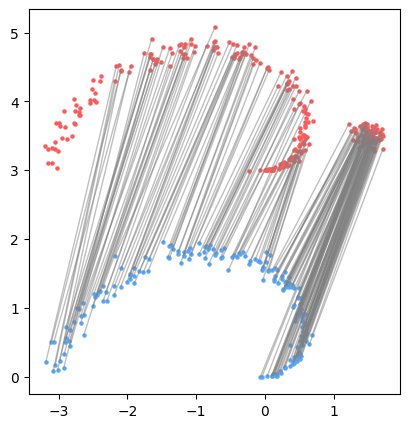

In [26]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(points_y[:,0], points_y[:,1] + 3, c='#ff5a5a', s=5)
ax.scatter(points_x[0][:,0], points_x[0][:,1], c='#55aaff', s=5)
ax.set_aspect('equal', 'box')

thresh = 1/10000
for i in range(pgw_mu.shape[0]):
    for j in range(pgw_mu.shape[1]):
        if pgw_mu[i,j] > thresh:
            ax.plot((points_y[j, 0],points_x[0][i, 0]), (points_y[j, 1] + 3,points_x[0][i, 1]), 'gray', 
                    alpha=100*float(pgw_mu[i][j]), lw=1)
plt.savefig('fig/PGW-coupling.svg')
plt.show()

In [27]:
print("PGW error: %.2f%%"%(100*pgw_mu[:,200:300].sum() / pgw_mu[:,:].sum(),))

PGW error: 48.00%


# MPGW

In [28]:
mpgw_mu = ot.partial.partial_gromov_wasserstein(d_x[0:-1, 0:-1], d_y, mu_x[0:-1,], mu_y)

C:\Users\artaj\AppData\Local\Temp\ipykernel_27012\1580148346.py:1: UserWarning: This function will be deprecated in a near future, please use ot.gromov.partial_gromov_wasserstein` instead.
  mpgw_mu = ot.partial.partial_gromov_wasserstein(d_x[0:-1, 0:-1], d_y, mu_x[0:-1,], mu_y)
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\ot\partial.py:808: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwggrad` instead.
  M = 0.5 * gwgrad_partial(
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\ot\partial.py:840: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwloss` instead.
  a = gwloss_partial(C1, C2, deltaG)
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\ot\partial.py:654: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwggrad` instead.
  g = gwgrad_partial(C1, C2, T) * 0.5


In [29]:
print("MPGW error: %.2f%%"%(100*mpgw_mu[:, 200:300].sum() / mpgw_mu[:,:].sum(),))

MPGW error: 48.00%


# MPGW with random initializations

In [30]:
t = time.time()
mpgw_mu = ot.partial.partial_gromov_wasserstein(d_x[0:-1, 0:-1], d_y, mu_x[0:-1,], mu_y)
for k in range(10):
    G0 = create_random_perm_mat(mpgw_mu.shape)
    mpgw_mu = ot.partial.partial_gromov_wasserstein(d_x[0:-1, 0:-1], d_y, mu_x[0:-1,], mu_y, G0=G0)
    print("MPGW error at iteration %d: %.2f%%"%(k, 100*mpgw_mu[:, 200:300].sum() / mpgw_mu[:,:].sum(),))
print("Total time: ", time.time()-t)

C:\Users\artaj\AppData\Local\Temp\ipykernel_27012\2332858977.py:2: UserWarning: This function will be deprecated in a near future, please use ot.gromov.partial_gromov_wasserstein` instead.
  mpgw_mu = ot.partial.partial_gromov_wasserstein(d_x[0:-1, 0:-1], d_y, mu_x[0:-1,], mu_y)
C:\Users\artaj\AppData\Local\Temp\ipykernel_27012\2332858977.py:5: UserWarning: This function will be deprecated in a near future, please use ot.gromov.partial_gromov_wasserstein` instead.
  mpgw_mu = ot.partial.partial_gromov_wasserstein(d_x[0:-1, 0:-1], d_y, mu_x[0:-1,], mu_y, G0=G0)


MPGW error at iteration 0: 48.00%
MPGW error at iteration 1: 48.00%
MPGW error at iteration 2: 48.00%
MPGW error at iteration 3: 48.00%
MPGW error at iteration 4: 48.00%
MPGW error at iteration 5: 48.00%
MPGW error at iteration 6: 48.00%
MPGW error at iteration 7: 23.50%
MPGW error at iteration 8: 48.00%
MPGW error at iteration 9: 48.00%
Total time:  5.208929777145386
